# Find alpha DSE1-4

May 4, 2025 - An attempt to reproduce the find alpha parameter using the DSE genes. The differences in the replicate fits and the shorter delta values make this procedure difficult to reliably reproduce consistently across both replicates. Replicate 1 produces very long alphas > 28, replicate 2 produces very short ones < 8. Whereas we would expect values between 12-20 proportionally to the length of the cell cycle as per Xin Guo's work.


In [11]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [12]:
from pipeline.CombinedDeconvolveGeneExpressionRunner import CombinedDeconvolveGeneExpressionRunner
output_directory = 'output/draft3_run/'
runner = CombinedDeconvolveGeneExpressionRunner(output_directory, False)

In [13]:
runner.config1.modify_alpha(30)

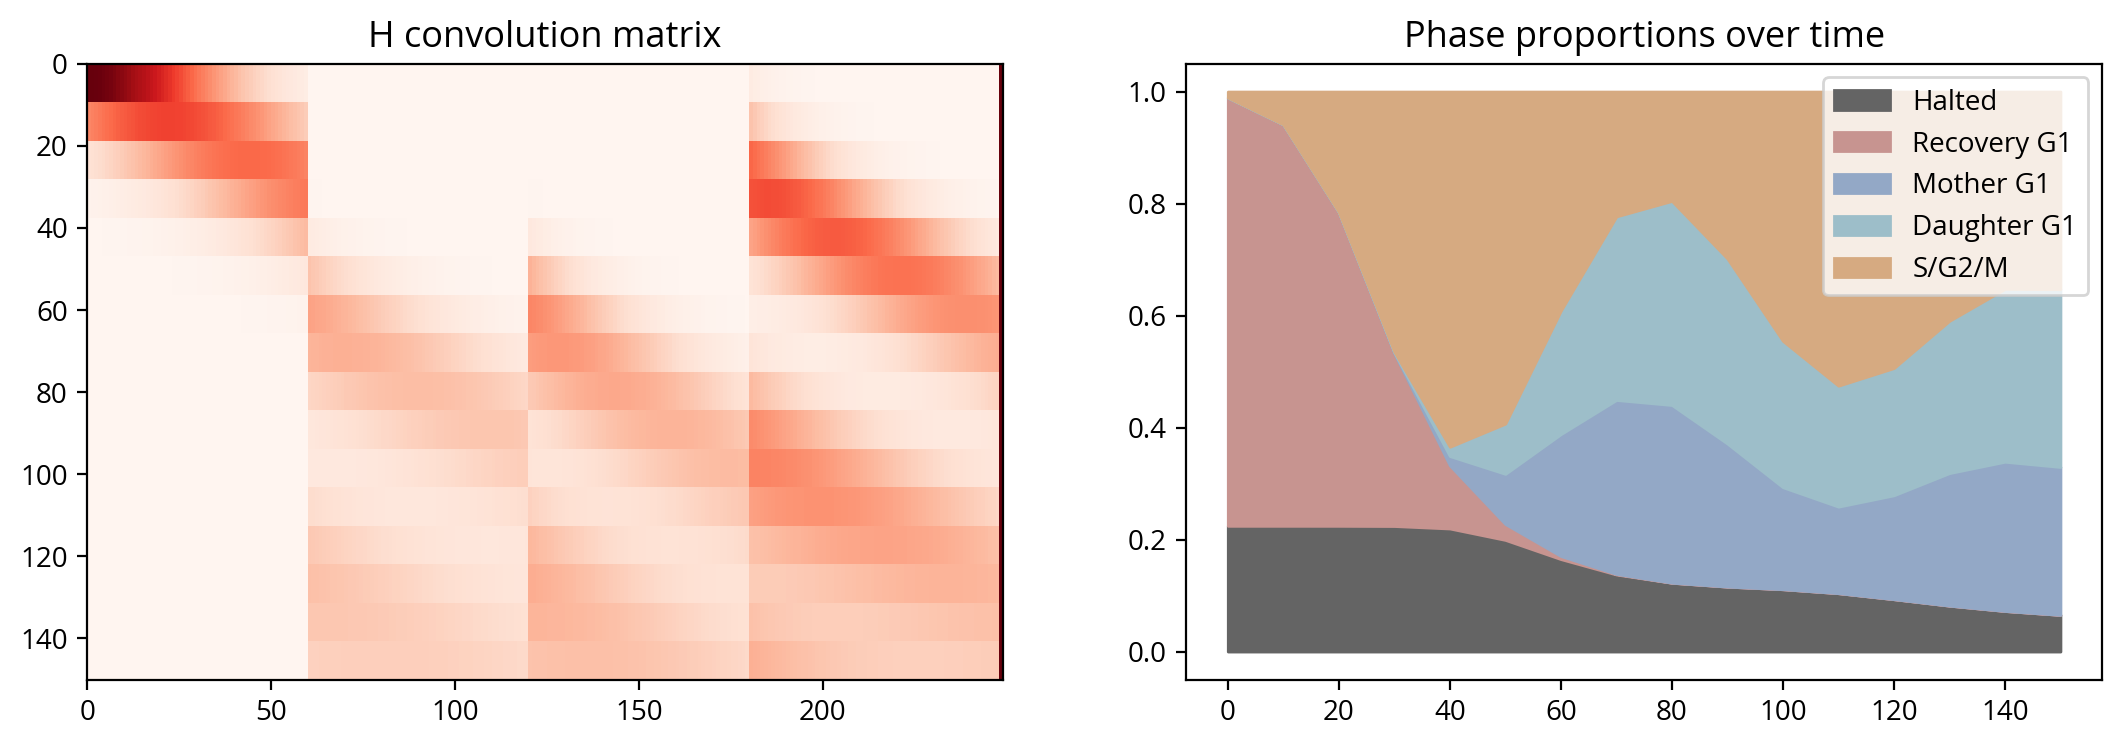

In [14]:
runner.config1.plot_H()

In [15]:
runner.deconvolve_gene_find_gamma('CLB2', replicate=1)

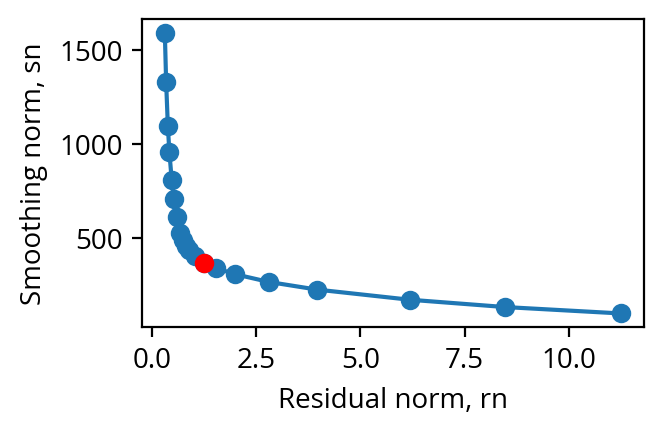

In [16]:
runner.expression_find_gamma.gamma_optimizer.plot_elbow()

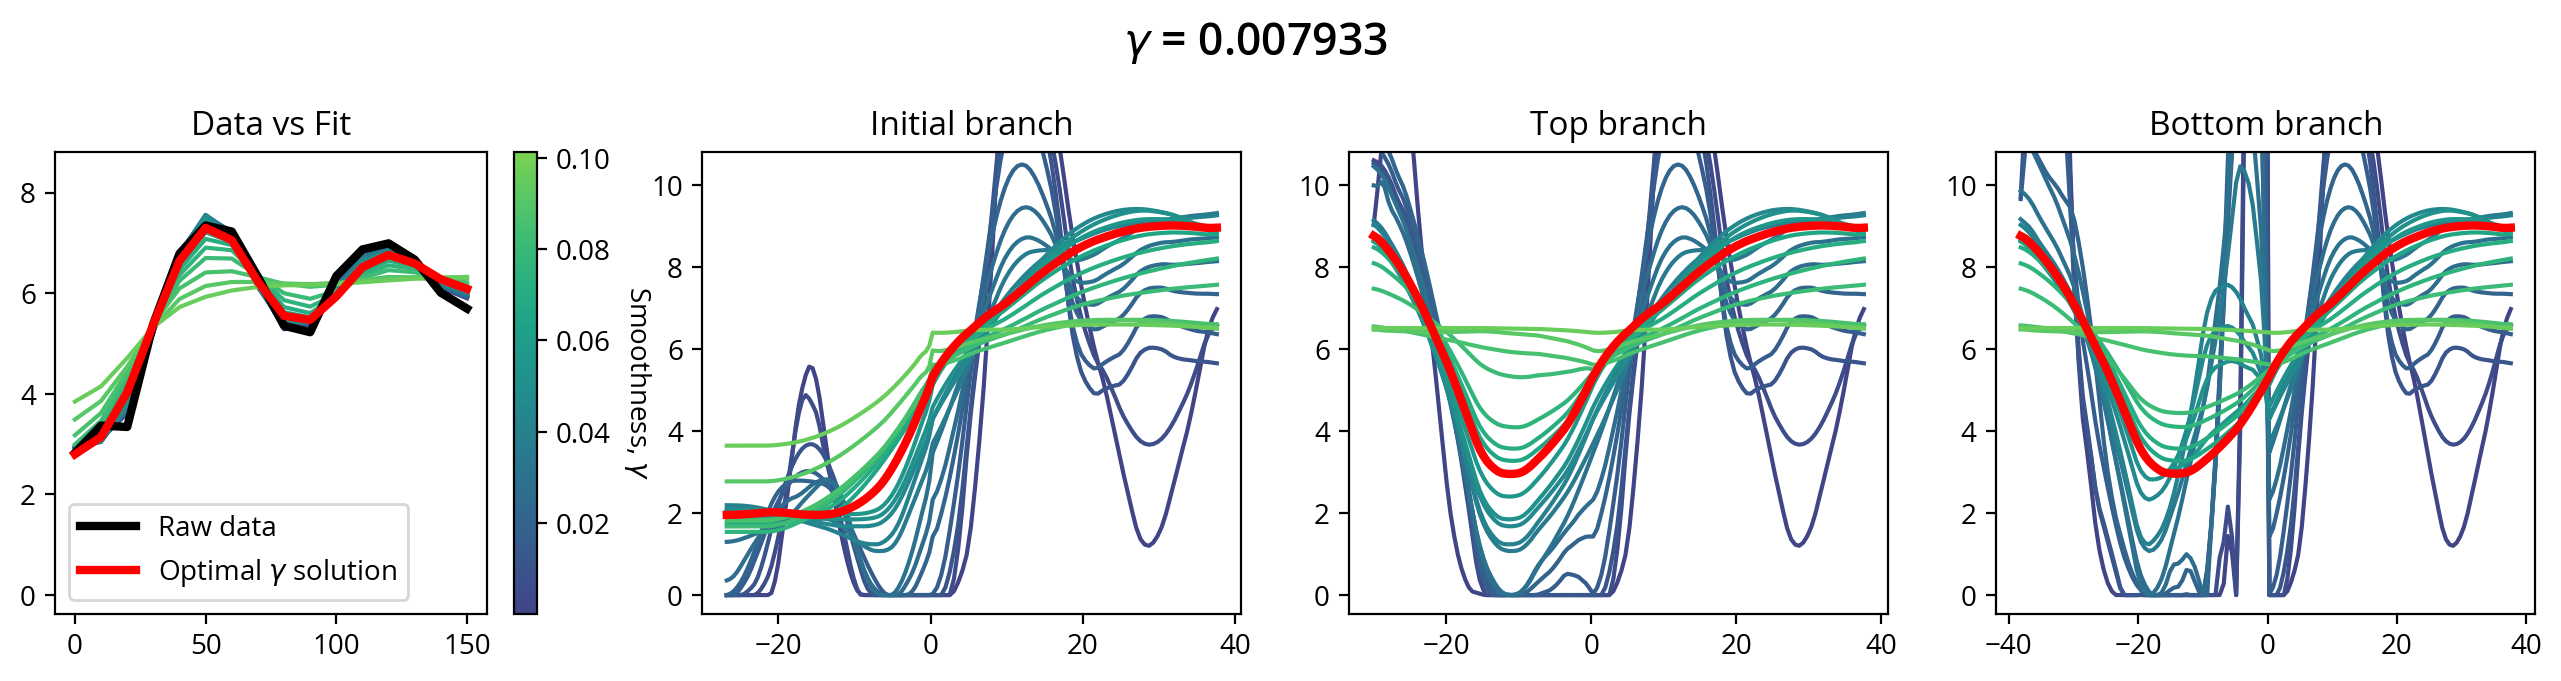

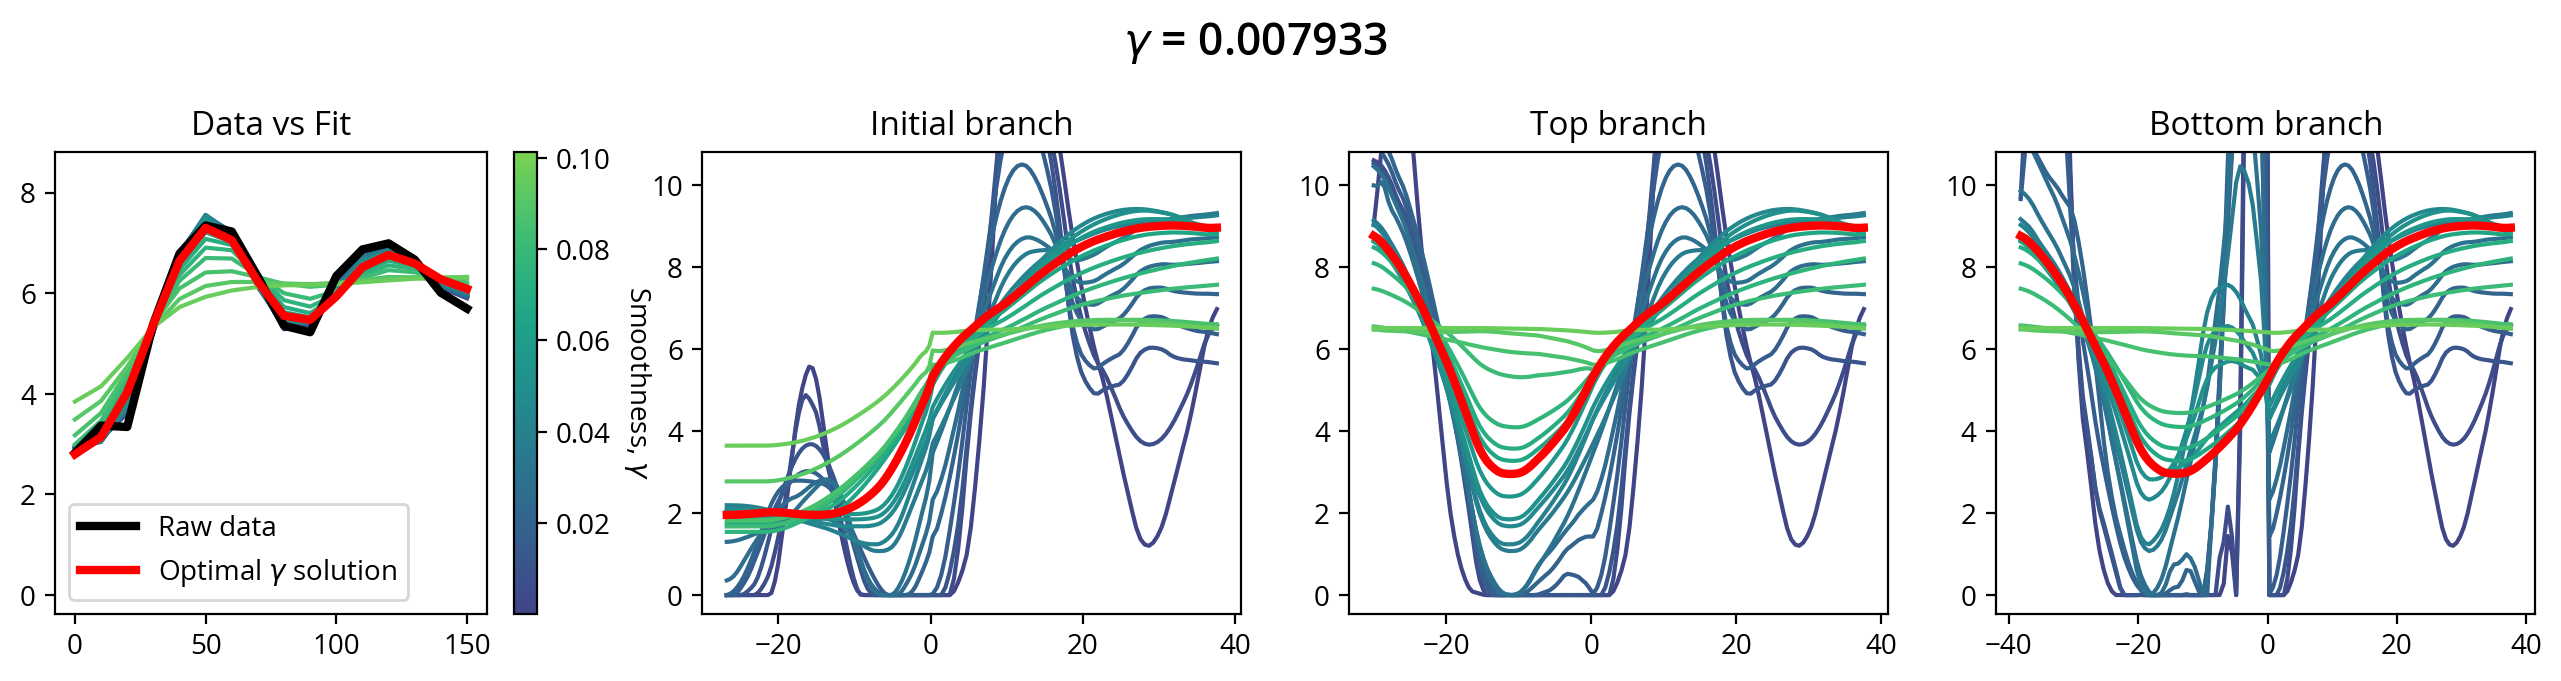

In [17]:
runner.expression_find_gamma.plot_gamma_sweep()

In [97]:
# Last check does the number of indices help?
from src.deconvolution_solver import DeconvolutionSolver
from src.deconvolution_solver_gpu import DeconvolutionSolver as DeconvolutionSolverGPU

config = runner.expression_find_gamma.deconvolution_solver.config

test_solver = DeconvolutionSolver(config,
    runner.expression_find_gamma.deconvolution_solver.g,
    config.H, 0.008, kappa=0.0)
test_solver.verbose=True
test_solver.deconvolve()


Fit norm: 1.105939294905579
Smoothing norm: 248.9583627131064
Initial smoothing result:  37.942194657994165
Top smoothing result:  88.64582859065523
Bottom smoothing result:  84.42814480646284


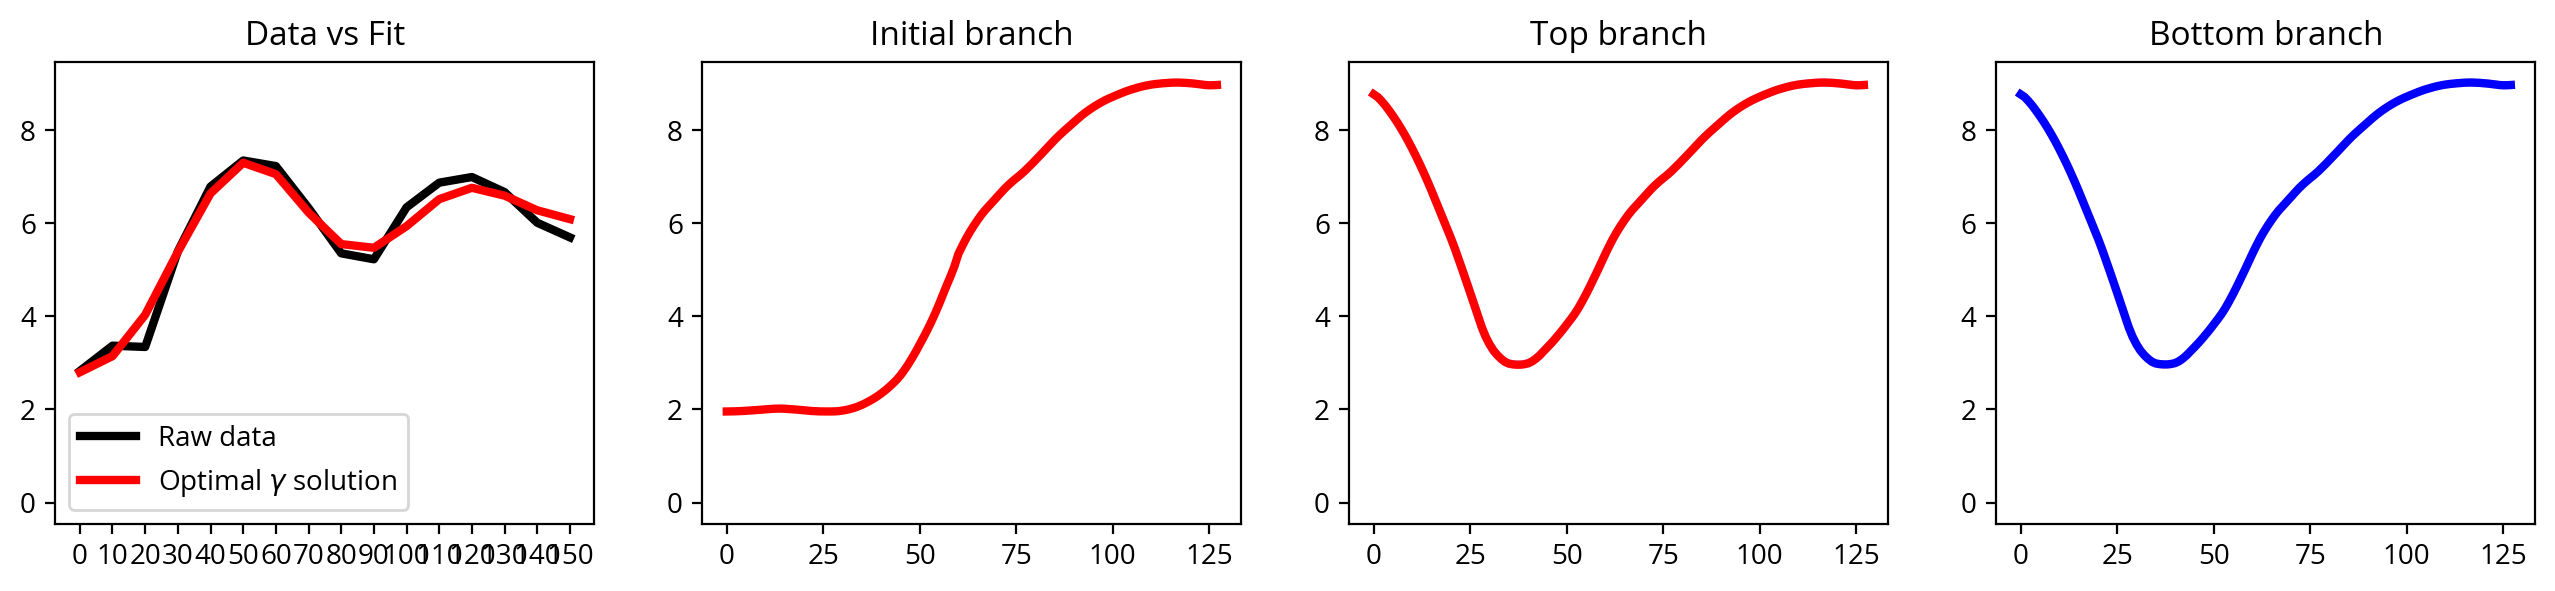

In [19]:
test_solver.plot_fit()

In [28]:
prob, f_baseline, f_variation = test_solver.deconvolve()

In [61]:
import cvxpy as cp
import torch
from cvxpylayers.torch import CvxpyLayer
from src.helpers import get_wavelet_kernel

f_i = config.get_Hpositions_for_branch('i')
f_t = config.get_Hpositions_for_branch('t')
f_b = config.get_Hpositions_for_branch('b')
f_cg1 = config.get_Hpositions_for_phase('CG1')
f_rg1 = config.get_Hpositions_for_phase('RG1')
f_dg1 = config.get_Hpositions_for_phase('DG1')
f_postg1 = config.get_Hpositions_for_phase('postG1')
f_halted = config.get_Hpositions_for_phase('Halted')
        
H = test_solver.H
g = test_solver.g.values
gamma = 0.006
W = get_wavelet_kernel(256)

# -------------- cvxplayers ---------------

n, m = H.shape

H_param = cp.Parameter(H.shape)
g_param = cp.Parameter(g.shape)
gamma_param = cp.Parameter(nonneg=True)

# Define variables
f_variation = cp.Variable(m)
f_baseline = cp.Variable(1)

# Set parameter values
H_param.value = H
g_param.value = g
gamma_param.value = gamma

# Important: Use the parameter objects in your problem definition
elementwise_result = H_param @ f_variation - g_param
fit_norm_result = cp.square(cp.norm(elementwise_result, 2))

# Sample smoothing constraint
f_t_coefficients = W@f_variation[np.concatenate([f_t, f_t])]

# Since you're not using gamma_param yet, let's add it
reg_term = gamma_param * cp.sum(cp.abs(f_t_coefficients))

objective = cp.Minimize(
    fit_norm_result + reg_term  # Added regularization with gamma_param
)

constraints = [f_variation >= 0, f_baseline == 0]

prob = cp.Problem(objective, constraints)

# Create layer with ONLY the parameters used in the problem
layer = CvxpyLayer(prob, 
                  parameters=[H_param, g_param, gamma_param], 
                  variables=[f_variation, f_baseline])

# Solve with PyTorch - match the order of parameters
f_variation_torch, f_baseline_torch = layer(
    torch.tensor(H).float(),  # Convert to float for torch
    torch.tensor(g).float(), 
    torch.tensor(gamma).float()
)

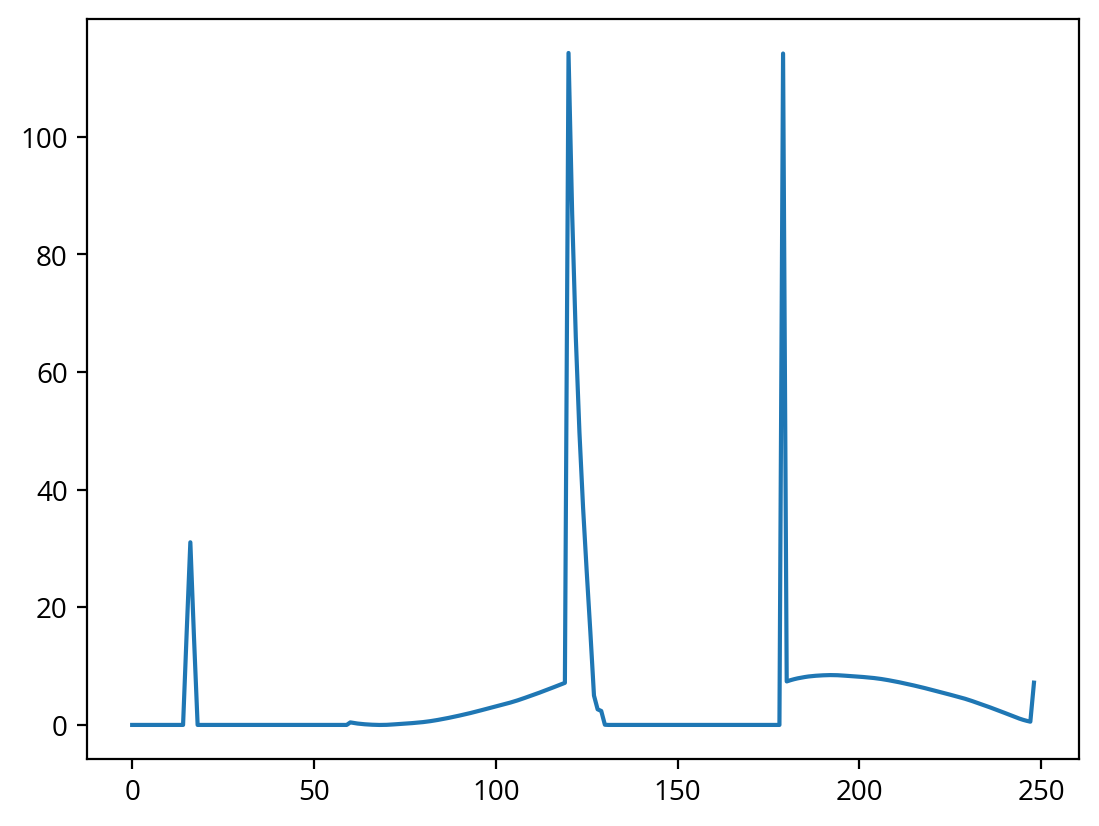

In [62]:
plt.plot(f_variation_torch.numpy())

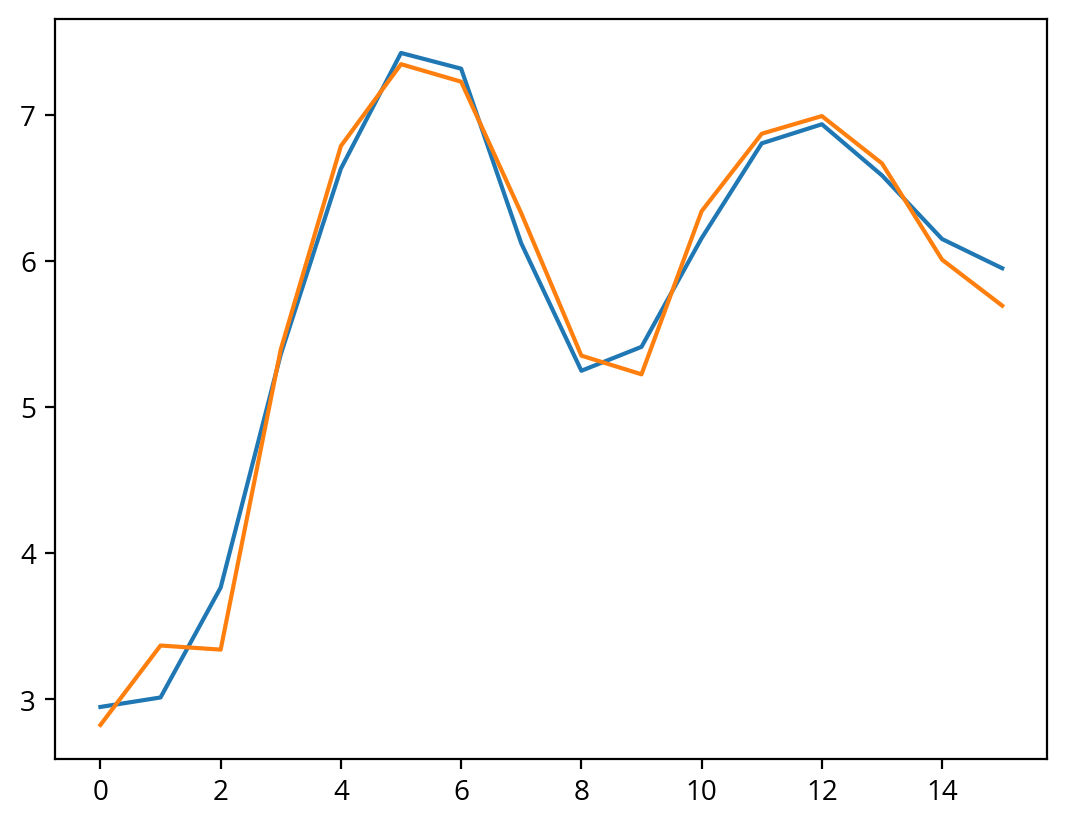

In [63]:
plt.plot(H@f_variation_torch.numpy())
plt.plot(g)

In [67]:
import cvxpy as cp
import torch
from cvxpylayers.torch import CvxpyLayer
from src.helpers import get_wavelet_kernel

# Setup values
f_i = config.get_Hpositions_for_branch('i')
f_t = config.get_Hpositions_for_branch('t')
f_b = config.get_Hpositions_for_branch('b')
f_cg1 = config.get_Hpositions_for_phase('CG1')
f_rg1 = config.get_Hpositions_for_phase('RG1')
f_dg1 = config.get_Hpositions_for_phase('DG1')
f_postg1 = config.get_Hpositions_for_phase('postG1')
f_halted = config.get_Hpositions_for_phase('Halted')

H = test_solver.H
g = test_solver.g.values
gamma = 0.006
W = get_wavelet_kernel(256)

n, m = H.shape

# Create a dummy parameter that won't affect optimization
dummy_param = cp.Parameter(1, nonneg=True)

# Define variables
f_variation = cp.Variable(m)
f_baseline = cp.Variable(1)

# Use constants directly in problem formulation
elementwise_result = H @ f_variation - g
fit_norm_result = cp.square(cp.norm(elementwise_result, 2))

# Sample smoothing constraint for top branch
f_t_coefficients = W @ f_variation[np.concatenate([f_t, f_t])]

# Use gamma as a constant
reg_term = gamma * cp.sum(cp.abs(f_t_coefficients))

objective = cp.Minimize(
    fit_norm_result + reg_term + 0 * dummy_param  # dummy_param doesn't affect the result
)

constraints = [f_variation >= 0, f_baseline == 0]

prob = cp.Problem(objective, constraints)

# Create layer with dummy parameter
layer = CvxpyLayer(prob, 
                  parameters=[dummy_param], 
                  variables=[f_variation, f_baseline])

# Call with dummy tensor
f_variation_torch, f_baseline_torch = layer(torch.tensor([1.0]).float())

print("Success! Layer executed with dummy parameter.")
print(f"Result shape: {f_variation_torch.shape}")

# Convert back to numpy if needed
f_variation_numpy = f_variation_torch.detach().cpu().numpy()
f_baseline_numpy = f_baseline_torch.detach().cpu().numpy()

Success! Layer executed with dummy parameter.
Result shape: torch.Size([249])


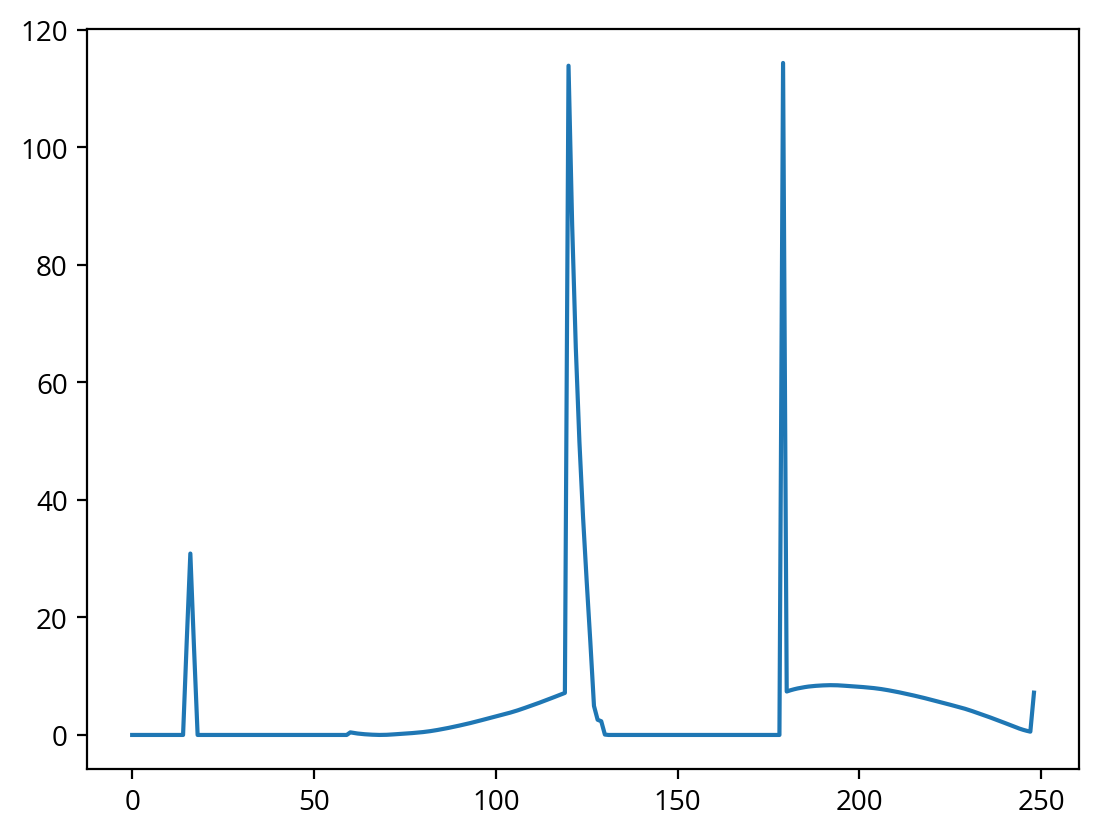

In [68]:
plt.plot(f_variation_numpy)

In [112]:
from src.deconvolution_solver_gpu import DeconvolutionSolver as DeconvolutionSolverGPU

test_solver_gpu = DeconvolutionSolverGPU(config,
    runner.expression_find_gamma.deconvolution_solver.g,
    config.H, 0.008, kappa=0.0, use_gpu=True, verbose=True)


True


In [114]:
from src.timer import Timer
timer = Timer()
test_solver_gpu.deconvolve()
timer.print_time()

Fit norm: None
Smoothing norm: None
Initial smoothing result: None
Top smoothing result: None
Bottom smoothing result: None
Solved using GPU acceleration via CVXPYLayers
00:00:00.351


In [115]:
timer = Timer()
test_solver.deconvolve()
timer.print_time()

Fit norm: 1.105939294905579
Smoothing norm: 248.9583627131064
Initial smoothing result:  37.942194657994165
Top smoothing result:  88.64582859065523
Bottom smoothing result:  84.42814480646284
00:00:00.163
